# Vaciada Paradox
> Why Spain is filling with tourists and emptying of Spaniards

## Setup
Standard imports for the project: eurostat for the Eurostat API, pandas and numpy for everything downstream. Matplotlib and scikit-learn come in later where they're first needed rather than upfront.

In [1]:
import eurostat
import pandas as pd
import numpy as np

## Data acquisition: tourism
The tourism data comes from Eurostat's tour_occ_nin2, "Nights spent at tourist accommodation establishments by NUTS-2 region." Nights rather than arrivals is the right unit here — a tourist staying ten days exerts ten times the demographic load of one staying overnight. NUTS-2 is the EU's harmonized regional classification, so the same dataset gives comparable units across 36 countries. The raw download is a wide DataFrame with years 1990–2025 as columns; a local CSV copy lets us iterate without re-pulling from the API.

In [2]:
tourism_raw = eurostat.get_data_df('tour_occ_nin2')

print(tourism_raw.shape)
tourism_raw.head()

(32322, 41)


,freq,c_resid,unit,nace_r2,geo\TIME_PERIOD,1990,1991,1992,1993,1994,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,A,DOM,NR,I551,AL,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,804181.0,1015037.0,729659.0,1076608.0,1237862.0,1943039.0,2039675.0,NaN
1,A,DOM,NR,I551,AL0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,804181.0,1015037.0,729659.0,1076608.0,1237862.0,1943039.0,2039675.0,NaN
2,A,DOM,NR,I551,AL01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,199081.0,259910.0,148755.0,206227.0,261012.0,467356.0,501278.0,NaN
3,A,DOM,NR,I551,AL02,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,269005.0,329702.0,164554.0,245447.0,372722.0,514057.0,598752.0,NaN
4,A,DOM,NR,I551,AL03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,336095.0,425425.0,416350.0,624934.0,604128.0,961626.0,939645.0,NaN


In [3]:
tourism_raw.to_csv('../data/raw/tour_occ_nin2.csv', index=False)

In [4]:
print(tourism_raw['c_resid'].unique())
print(tourism_raw['unit'].unique())
print(tourism_raw['nace_r2'].unique())

<StringArray>
['DOM', 'FOR', 'TOTAL']
Length: 3, dtype: str
<StringArray>
['NR', 'PCH_PRE', 'PC_TOT', 'P_KM2', 'P_THAB']
Length: 5, dtype: str
<StringArray>
['I551', 'I551-I553', 'I552', 'I552_I553', 'I553']
Length: 5, dtype: str


## Preparing the tourism dataset
The raw data needs four reductions before it's analytically useful. First, the filter: TOTAL residents (combining foreign and domestic tourists), NR (raw counts rather than pre-normalized intensity), nace_r2 = I551-I553 (all accommodation types together), and geo codes of length 4 (NUTS-2 only, dropping country aggregates and finer NUTS-3). Second, melt to long format — year columns become rows, which makes downstream filtering and aggregation standard. Third, the cleanup chain: cast year to int, drop NaN, drop the now-constant dimension columns, rename the awkward geo\TIME_PERIOD column. Fourth, the analytical window: 2018–2024 captures the modern overtourism era plus post-COVID normalization while excluding 2017 (anomalously thin coverage) and 2025 (incomplete reporting). After dropping the EU27 aggregate that snuck through the length filter, tourism intensity for the cross-sectional analysis is computed as the 2022–2024 mean per region — smoothing post-COVID volatility, particularly the 2023 "revenge tourism" spike across Southern Europe that disproportionately inflated Mediterranean values in that year.

In [5]:
tourism_nuts2 = tourism_raw[(tourism_raw['c_resid'] == 'TOTAL') & (tourism_raw['unit'] == 'NR') & (tourism_raw['nace_r2'] == 'I551-I553') & (tourism_raw[r'geo\TIME_PERIOD'].str.len() == 4)]

print(tourism_nuts2.shape)
tourism_nuts2.head()

(386, 41)


,freq,c_resid,unit,nace_r2,geo\TIME_PERIOD,1990,1991,1992,1993,1994,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
20405,A,TOTAL,NR,I551-I553,AL01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,915992.0,1078360.0,461798.0,825761.0,981124.0,1560639.0,1671619.0,NaN
20411,A,TOTAL,NR,I551-I553,AL02,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1095904.0,1076512.0,488603.0,1145547.0,1557837.0,2243740.0,3148479.0,NaN
20414,A,TOTAL,NR,I551-I553,AL03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1062761.0,1098547.0,655043.0,1214764.0,1292368.0,2203475.0,2625616.0,NaN
20422,A,TOTAL,NR,I551-I553,AT11,1702891.0,1811295.0,1796171.0,1775825.0,1768899.0,...,2785313.0,2781046.0,2732386.0,2807665.0,1990790.0,2186092.0,2610132.0,2842291.0,2983732.0,3064795.0
20426,A,TOTAL,NR,I551-I553,AT12,5864129.0,5837344.0,5585911.0,5499808.0,5336793.0,...,6213061.0,6491384.0,6700076.0,6931168.0,3987757.0,4405820.0,5891034.0,6581820.0,6604761.0,6551649.0


In [6]:
tourism_long = tourism_nuts2.melt(id_vars = ['freq', 'c_resid', 'unit', 'nace_r2', r'geo\TIME_PERIOD'], var_name = 'year', value_name = 'nights')

print(tourism_long.shape)
tourism_long.head()

(13896, 7)


,freq,c_resid,unit,nace_r2,geo\TIME_PERIOD,year,nights
0,A,TOTAL,NR,I551-I553,AL01,1990,NaN
1,A,TOTAL,NR,I551-I553,AL02,1990,NaN
2,A,TOTAL,NR,I551-I553,AL03,1990,NaN
3,A,TOTAL,NR,I551-I553,AT11,1990,1702891.0
4,A,TOTAL,NR,I551-I553,AT12,1990,5864129.0


In [7]:
tourism_long['year'] = tourism_long['year'].astype(int)
tourism_long = tourism_long.dropna(subset=['nights']).reset_index(drop=True)
tourism_long = tourism_long.drop(columns=['freq', 'c_resid', 'unit', 'nace_r2'])
tourism_long = tourism_long.rename(columns={r'geo\TIME_PERIOD' : 'geo'})

print(tourism_long.shape)
tourism_long.head()

(8203, 3)


,geo,year,nights
0,AT11,1990,1702891.0
1,AT12,1990,5864129.0
2,AT13,1990,7292579.0
3,AT21,1990,12300684.0
4,AT22,1990,7117490.0


In [8]:
tourism_long.groupby('year')['geo'].nunique()

year
1990    133
1991     84
1992     84
1993     76
1994     85
1995    154
1996    135
1997    136
1998    185
1999    184
2000    224
2001    247
2002    257
2003    257
2004    271
2005    268
2006    270
2007    270
2008    271
2009    258
2010    270
2011    260
2012    266
2013    270
2014    274
2015    317
2016    326
2017    249
2018    281
2019    284
2020    285
2021    292
2022    293
2023    297
2024    295
2025     95
Name: geo, dtype: int64

In [9]:
tourism_window = tourism_long[tourism_long['year'].between(2018, 2024)]

print(tourism_window.shape)
tourism_window.head()

(2027, 3)


,geo,year,nights
6081,AL01,2018,915992.0
6082,AL02,2018,1095904.0
6083,AL03,2018,1062761.0
6084,AT11,2018,2732386.0
6085,AT12,2018,6700076.0


In [10]:
tourism_window['country'] = tourism_window['geo'].str[:2]

print(tourism_window['country'].unique())

<StringArray>
['AL', 'AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'EU',
 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LI', 'LT', 'LU', 'LV', 'MK', 'MT', 'NL',
 'PL', 'PT', 'RO', 'SE', 'SK', 'TR', 'IS', 'SI', 'NO', 'RS', 'ME', 'EA']
Length: 38, dtype: str


In [11]:
tourism_window = tourism_window[tourism_window['country'] != 'EU']

print(tourism_window['country'].unique())

<StringArray>
['AL', 'AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI',
 'FR', 'HR', 'HU', 'IE', 'IT', 'LI', 'LT', 'LU', 'LV', 'MK', 'MT', 'NL', 'PL',
 'PT', 'RO', 'SE', 'SK', 'TR', 'IS', 'SI', 'NO', 'RS', 'ME', 'EA']
Length: 37, dtype: str


In [12]:
# Diagnostic 1: NUTS-2 geo code stability across 2018-2024 in tourism data

# Unique geos per year — first sanity check
print("Unique geo codes per year:")
print(tourism_window.groupby('year')['geo'].nunique())
print()

# Presence matrix: 1 if a geo has data in that year, 0 otherwise
tourism_presence = (
    tourism_window.assign(present=1)
    .pivot_table(index='geo', columns='year', values='present', fill_value=0)
    .astype(int)
)

# Geos that are missing from at least one year
inconsistent = tourism_presence[(tourism_presence == 0).any(axis=1)]
print(f"Geos with gaps in at least one year: {len(inconsistent)}")
if len(inconsistent) > 0:
    print(inconsistent)

Unique geo codes per year:
year
2018    279
2019    282
2020    285
2021    292
2022    293
2023    297
2024    295
Name: geo, dtype: int64

Geos with gaps in at least one year: 36
year  2018  2019  2020  2021  2022  2023  2024
geo                                           
CH01     1     1     0     1     1     1     1
CH02     1     1     0     1     1     1     1
CH03     1     1     0     1     1     1     1
CH04     1     1     0     1     1     1     1
CH05     1     1     0     1     1     1     1
CH06     1     1     0     1     1     1     1
CH07     1     1     0     1     1     1     1
EA20     0     0     0     0     0     0     1
HR04     1     1     0     0     0     0     0
IS00     0     1     1     1     1     1     0
ME00     0     0     0     0     1     1     1
NL31     1     1     1     1     1     1     0
NL33     1     1     1     1     1     1     0
NL35     0     0     0     0     0     1     1
NL36     0     0     0     0     0     1     1
NO02     0     0    

In [13]:
# Tourism intensity measured as the 2022-2024 mean per region, to smooth
# the 2023 "revenge tourism" spike across Southern Europe that disproportionately
# inflated Mediterranean intensity in that year.

tourism_smoothed = (
    tourism_window[tourism_window['year'].between(2022, 2024)]
    .groupby('geo', as_index=False)['nights']
    .mean()
)

# Re-derive country column (lost in groupby)
tourism_smoothed['country'] = tourism_smoothed['geo'].str[:2]

print(tourism_smoothed.shape)
tourism_smoothed.head()

(301, 3)


,geo,nights,country
0,AL01,1.404461e+06,AL
1,AL02,2.316685e+06,AL
2,AL03,2.040486e+06,AL
3,AT11,2.812052e+06,AT
4,AT12,6.359205e+06,AT


## Measuring tourism concentration
The analytical question isn't how much tourism each country receives but how concentrated that tourism is within its regions — whether the burden falls on a few coastal hotspots or spreads across the whole country. The Gini coefficient handles this: 0 means tourism is distributed perfectly evenly, 1 means a single region holds everything. The function is hand-written rather than imported so the math is visible; two sanity checks at boundary cases confirm it behaves correctly. Applied per country via groupby, the result is a Series of tourism concentration indices comparable across nations of different sizes. Countries with only a single NUTS-2 region get a mechanical 0 (no within-country variance possible) and are filtered out of the ranking. Countries with fewer than six NUTS-2 regions are also excluded, since small-sample inequality estimates are noisy. A second metric, the top-3 concentration ratio (CR-3), is retained across all multi-region countries as a descriptive complement — producing the kind of human-readable number that carries a sentence: "53% of Spain's tourism happens in just three regions." Spain ranks second in Europe on Gini, behind Turkey alone; its top three regions turn out to be Canarias, Cataluña, and Andalucía — not the popular intuition of Madrid, Barcelona, and Mallorca.

In [14]:
def gini(values):
    """This function computes the gini coefficient - a number that describes tourism inequality"""
    arr = np.asarray(values)
    n = len(arr)
    sorted_arr = np.sort(arr)
    cumsum_of_sorted = np.cumsum(sorted_arr)
    total = cumsum_of_sorted[-1]
    result = (n + 1 - 2 * cumsum_of_sorted.sum() / total) / n
    return result

In [15]:
gini_by_country = tourism_smoothed.groupby('country')['nights'].apply(gini)

gini_by_country = gini_by_country.sort_values(ascending=False)

gini_by_country

country
TR    0.717837
HR    0.703681
ES    0.612369
FR    0.572518
EL    0.547685
PL    0.448936
IT    0.445610
BG    0.412649
BE    0.403846
DE    0.390899
PT    0.385739
AT    0.381744
NO    0.372067
NL    0.368942
HU    0.330569
FI    0.327336
CZ    0.304214
CH    0.291171
DK    0.283366
SE    0.255613
RO    0.241405
LT    0.198617
RS    0.192637
SI    0.179485
SK    0.133073
AL    0.105552
IE    0.073043
MT    0.000000
MK    0.000000
ME    0.000000
LV    0.000000
LU    0.000000
LI    0.000000
EE    0.000000
EA    0.000000
CY    0.000000
IS    0.000000
Name: nights, dtype: float64

In [16]:
tourism_smoothed.groupby('country').size().sort_values()

country
IS     1
MT     1
MK     1
ME     1
CY     1
LV     1
LU     1
EA     1
EE     1
LI     1
SI     2
LT     2
IE     3
AL     3
HR     4
SK     4
RS     4
FI     5
DK     5
BG     6
NO     7
CH     7
RO     8
CZ     8
HU     8
SE     8
AT     9
BE    11
PT    12
EL    13
NL    14
PL    17
ES    19
IT    21
TR    26
FR    27
DE    38
dtype: int64

In [17]:
region_counts = tourism_smoothed.groupby('country').size().sort_values()

multi_region_countries = region_counts[region_counts >= 2].index

tourism_smoothed_multi = tourism_smoothed[tourism_smoothed['country'].isin(multi_region_countries)]

tourism_smoothed_multi['country'].nunique()

27

In [18]:
# Reviewer note: country-level Gini is unreliable when n < 6 (small-sample noise
# dominates the estimate). Restrict the ranking to countries with at least 6
# NUTS-2 regions. CR-3 is retained across all multi-region countries.

reliable_gini_countries = region_counts[region_counts >= 6].index
gini_reliable = gini_by_country[gini_by_country.index.isin(reliable_gini_countries)]
gini_reliable = gini_reliable.sort_values(ascending=False)

print(f"Countries with n >= 6 NUTS-2 regions: {len(reliable_gini_countries)}")
print()
print("Gini coefficient (n >= 6 only, sorted descending):")
print(gini_reliable)

Countries with n >= 6 NUTS-2 regions: 18

Gini coefficient (n >= 6 only, sorted descending):
country
TR    0.717837
ES    0.612369
FR    0.572518
EL    0.547685
PL    0.448936
IT    0.445610
BG    0.412649
BE    0.403846
DE    0.390899
PT    0.385739
AT    0.381744
NO    0.372067
NL    0.368942
HU    0.330569
CZ    0.304214
CH    0.291171
SE    0.255613
RO    0.241405
Name: nights, dtype: float64


In [19]:
def concentration_ratio(values, n):
    arr = np.asarray(values)
    arr_sorted = np.sort(arr)[::-1]
    top_n = arr_sorted[:n]
    result = top_n.sum()/arr.sum()
    
    return result

print(concentration_ratio([10, 0, 0, 0], 1))
print(concentration_ratio([1, 1, 1, 1], 1))
print(concentration_ratio([5, 3, 2, 1, 1], 3))

1.0
0.25
0.8333333333333334


In [20]:
cr3_by_country = tourism_smoothed_multi.groupby('country')['nights'].apply(concentration_ratio, n=3)

cr3_by_country = cr3_by_country.sort_values(ascending=False)

cr3_by_country

country
AL    1.000000
SI    1.000000
LT    1.000000
IE    1.000000
HR    0.987355
RS    0.842451
FI    0.837906
SK    0.826829
BG    0.807632
DK    0.787333
TR    0.720116
NO    0.693538
CH    0.665300
EL    0.632310
HU    0.629417
AT    0.623252
CZ    0.588538
SE    0.567144
RO    0.560742
BE    0.555452
ES    0.525288
PT    0.523276
PL    0.437291
NL    0.427747
FR    0.422284
IT    0.361984
DE    0.247071
Name: nights, dtype: float64

In [21]:
tourism_spain_2023 = tourism_smoothed_multi[tourism_smoothed_multi['country'] == 'ES']

tourism_spain_2023 = tourism_spain_2023.sort_values('nights', ascending=False)

tourism_spain_2023

,geo,nights,country
121,ES70,9.477694e+07,ES
114,ES51,8.472113e+07,ES
117,ES61,7.295145e+07,ES
116,ES53,6.933693e+07,ES
115,ES52,5.182086e+07,ES
110,ES30,2.975431e+07,ES
103,ES11,1.315555e+07,ES
111,ES41,1.260882e+07,ES
106,ES21,9.622971e+06,ES
109,ES24,8.537820e+06,ES


## Data acquisition: population
The population data comes from Eurostat's demo_r_d2jan, "Population on 1 January by NUTS-2 region." Eurostat doesn't publish a demographic balance table at NUTS-2, so trends have to be computed from this stock series across years. The dataset is roughly five times the size of the tourism file because it's broken down by sex and age as well as geography.

In [22]:
pop_raw = eurostat.get_data_df('demo_r_d2jan')

print(pop_raw.shape)
pop_raw.head()

(160800, 41)


,freq,unit,sex,age,geo\TIME_PERIOD,1990,1991,1992,1993,1994,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,A,NR,F,TOTAL,AL,NaN,NaN,NaN,NaN,NaN,...,1417141.0,1423050.0,1431715.0,1432833.0,1425342.0,1419759.0,1406532.0,1394864.0,NaN,1194597.0
1,A,NR,F,TOTAL,AL0,NaN,NaN,NaN,NaN,NaN,...,1417141.0,1423050.0,1431715.0,1432833.0,1425342.0,1419759.0,1406532.0,1394864.0,NaN,1194597.0
2,A,NR,F,TOTAL,AL01,NaN,NaN,NaN,NaN,NaN,...,406682.0,405835.0,405598.0,404201.0,399599.0,396799.0,390886.0,385462.0,NaN,317141.0
3,A,NR,F,TOTAL,AL02,NaN,NaN,NaN,NaN,NaN,...,564402.0,574010.0,585530.0,590623.0,594008.0,596005.0,597622.0,598531.0,NaN,506383.0
4,A,NR,F,TOTAL,AL03,NaN,NaN,NaN,NaN,NaN,...,446057.0,443205.0,440587.0,438009.0,431735.0,426955.0,418024.0,410871.0,NaN,371073.0


In [23]:
pop_raw.to_csv('../data/raw/demo_r_d2jan.csv', index=False)

In [24]:
print(pop_raw['freq'].unique())
print(pop_raw['unit'].unique())
print(pop_raw['sex'].unique())
print(pop_raw['age'].unique())
print(pop_raw[r'geo\TIME_PERIOD'].nunique())

<StringArray>
['A']
Length: 1, dtype: str
<StringArray>
['NR']
Length: 1, dtype: str
<StringArray>
['F', 'M', 'T']
Length: 3, dtype: str
<StringArray>
[ 'TOTAL',    'UNK',     'Y1',    'Y10',    'Y11',    'Y12',    'Y13',
    'Y14',    'Y15',    'Y16',
 ...
    'Y92',    'Y93',    'Y94',    'Y95',    'Y96',    'Y97',    'Y98',
    'Y99',  'Y_LT1', 'Y_OPEN']
Length: 103, dtype: str
521


## Preparing the population dataset
The cleaning follows the same shape as tourism: filter, melt, clean, window. The filter keeps sex = T (both sexes combined), age = TOTAL (all ages), unit = NR (raw counts), and geo length 4. After melt and the standard cleanup chain, the same 2018–2024 window applies for consistency with the tourism analysis. Eurostat marks extra-regio entries (maritime areas, embassies, oil platforms, unassigned populations) with codes ending in XX; these pass the length filter but have no real values and drop out via dropna.

In [25]:
pop_nuts2 = pop_raw[(pop_raw['sex'] == 'T') & (pop_raw['age'] == 'TOTAL') & (pop_raw[r'geo\TIME_PERIOD'].str.len() == 4)]

print(pop_nuts2.shape)
pop_nuts2.head()

(352, 41)


,freq,unit,sex,age,geo\TIME_PERIOD,1990,1991,1992,1993,1994,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
107202,A,NR,T,TOTAL,AL01,NaN,NaN,NaN,NaN,NaN,...,830981.0,826904.0,819793.0,813758.0,804689.0,797955.0,783970.0,771020.0,NaN,633710.0
107203,A,NR,T,TOTAL,AL02,NaN,NaN,NaN,NaN,NaN,...,1130587.0,1146183.0,1162544.0,1170142.0,1176240.0,1178435.0,1178623.0,1177987.0,NaN,986944.0
107204,A,NR,T,TOTAL,AL03,NaN,NaN,NaN,NaN,NaN,...,914024.0,903504.0,887987.0,878527.0,865026.0,853351.0,830999.0,812778.0,NaN,742660.0
107206,A,NR,T,TOTAL,ALXX,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
107209,A,NR,T,TOTAL,AT11,270670.0,271604.0,274259.0,275633.0,276300.0,...,291011.0,291942.0,292675.0,293433.0,294436.0,296010.0,297583.0,301250.0,301951.0,301790.0


In [26]:
pop_long = pop_nuts2.melt(id_vars = ['freq', 'sex', 'unit', 'age', r'geo\TIME_PERIOD'], var_name = 'year', value_name = 'population')

print(pop_long.shape)
pop_long.head()

(12672, 7)


,freq,sex,unit,age,geo\TIME_PERIOD,year,population
0,A,T,NR,TOTAL,AL01,1990,NaN
1,A,T,NR,TOTAL,AL02,1990,NaN
2,A,T,NR,TOTAL,AL03,1990,NaN
3,A,T,NR,TOTAL,ALXX,1990,NaN
4,A,T,NR,TOTAL,AT11,1990,270670.0


In [27]:
pop_long['year'] = pop_long['year'].astype(int)
pop_long = pop_long.dropna(subset=['population']).reset_index(drop=True)
pop_long = pop_long.drop(columns=['freq', 'sex', 'unit', 'age'])
pop_long = pop_long.rename(columns={r'geo\TIME_PERIOD' : 'geo'})

print(pop_long.shape)
pop_long.head()

(10383, 3)


,geo,year,population
0,AT11,1990,270670.0
1,AT12,1990,1455968.0
2,AT13,1990,1492636.0
3,AT21,1990,544983.0
4,AT22,1990,1169578.0


In [28]:
pop_window = pop_long[pop_long['year'].between(2018, 2024)]

In [29]:
pop_window = pop_window[~pop_window['geo'].str.startswith('EU')]

In [30]:
# Diagnostic 2: NUTS-2 geo code stability across 2018-2024 in population data

print("Unique geo codes per year:")
print(pop_window.groupby('year')['geo'].nunique())
print()

pop_presence = (
    pop_window.assign(present=1)
    .pivot_table(index='geo', columns='year', values='present', fill_value=0)
    .astype(int)
)

inconsistent_pop = pop_presence[(pop_presence == 0).any(axis=1)]
print(f"Geos with gaps in at least one year: {len(inconsistent_pop)}")
if len(inconsistent_pop) > 0:
    print(inconsistent_pop)

Unique geo codes per year:
year
2018    346
2019    345
2020    304
2021    300
2022    301
2023    301
2024    293
Name: geo, dtype: int64

Geos with gaps in at least one year: 64
year  2018  2019  2020  2021  2022  2023  2024
geo                                           
AL01     1     1     1     1     1     1     0
AL02     1     1     1     1     1     1     0
AL03     1     1     1     1     1     1     0
ALXX     1     1     0     0     0     0     0
FRXX     1     1     1     0     0     0     0
...    ...   ...   ...   ...   ...   ...   ...
UKM6     1     1     0     0     0     0     0
UKM7     1     1     0     0     0     0     0
UKM8     1     1     0     0     0     0     0
UKM9     1     1     0     0     0     0     0
UKN0     1     0     0     0     0     0     0

[64 rows x 7 columns]


## Population change
The data is in stocks — how many people lived in each region on January 1 of each year — but the analytical question is about trends. Pivoting to wide format with years as columns lets us subtract one year from another to get change. Six-year percentage change from 2018 to 2024 is the metric here: long enough to detect demographic trends, recent enough to capture the overtourism era, normalized for region size so a small region losing 5,000 people registers as more dramatic than a large region losing 100,000. The Spanish breakdown previews the larger story: the vaciada heartland (Extremadura, Castilla y León) loses population, consistent with the vaciada literature. The islands and Madrid gain, and Castilla-La Mancha is a surprise grower — Madrid metro spillover reaching into Guadalajara and Toledo.

In [31]:
pop_wide = pop_window.pivot(index='geo', columns='year', values='population')

pop_change_pct = (pop_wide[2024] - pop_wide[2018]) / pop_wide[2018] * 100

pop_change_pct.sort_values()

geo
MK00   -11.992677
BG31    -9.875839
HR02    -9.153552
BG32    -9.080352
PL72    -8.836168
          ...    
UKM6          NaN
UKM7          NaN
UKM8          NaN
UKM9          NaN
UKN0          NaN
Length: 351, dtype: float64

In [32]:
pop_change_pct[pop_change_pct.index.str.startswith('ES')].sort_values()

geo
ES63   -2.517374
ES12   -1.703062
ES43   -1.681705
ES41   -1.048029
ES64   -0.115004
ES11    0.103032
ES13    1.602317
ES21    1.848436
ES61    2.803537
ES24    2.900510
ES23    2.951507
ES42    3.441982
ES22    4.949872
ES70    5.027864
ES62    6.071070
ES51    6.271975
ES52    7.274274
ES30    7.340745
ES53    7.933086
dtype: float64

## The cross-EU question
With both datasets in hand, the simple version of the vaciada hypothesis is testable: tourism-intense regions should show population decline. Building analysis_df joins three sources on the geo index — 2022–2024 mean tourism nights, 2023 population stock (the per-capita denominator), and 2018–2024 population change. Tourism intensity is measured per capita rather than in raw nights; a region with 100 million tourist nights and 2 million residents is meaningfully different from one with the same nights and 200,000 residents. The result across 277 multi-region European NUTS-2 units: correlation between tourism intensity and population change = 0.05. Essentially zero. The simple hypothesis fails at this aggregation. But a null aggregate correlation can hide distinct typologies — different kinds of regions behaving in opposite ways that cancel out in the average. That's what the next section is for.

In [33]:
# Diagnostic 3: identify which tourism geos drop out of analysis_df due to missing population values

check_df = (
    tourism_smoothed_multi[['geo']]
    .set_index('geo')
    .join(pop_wide[[2018, 2023, 2024]])
)

dropping = check_df[check_df.isna().any(axis=1)]

print(f"Tourism geos entering analysis_df build: {len(check_df)}")
print(f"Geos that will drop due to missing pop data: {len(dropping)}")
print(f"Geos surviving to analysis_df: {len(check_df) - len(dropping)}")
print()
print("Which geos drop and which years are missing (NaN = missing):")
print(dropping)

Tourism geos entering analysis_df build: 291
Geos that will drop due to missing pop data: 13
Geos surviving to analysis_df: 278

Which geos drop and which years are missing (NaN = missing):
           2018       2023       2024
geo                                  
AL01   819793.0   771020.0        NaN
AL02  1162544.0  1177987.0        NaN
AL03   887987.0   812778.0        NaN
NL31  1295484.0  1387643.0        NaN
NL33  3681044.0  3804906.0        NaN
PT16  2235005.0  2264956.0        NaN
PT17  2849085.0  2921564.0        NaN
PT18   713125.0   716994.0        NaN
PT19        NaN  1672267.0  1695635.0
PT1A        NaN  2097742.0  2126578.0
PT1B        NaN   823822.0   834599.0
PT1C        NaN   472735.0   474701.0
PT1D        NaN   836948.0   852583.0


## Note on NUTS revisions and missing values

Building `analysis_df` requires both 2023 tourism nights and a 2018-to-2024 population delta on the same `geo` index, and the `dropna()` step at the end of the join silently removes 10 of 288 multi-region tourism regions due to missing population values. The three causes: Albania's NUTS-2 regions (AL01, AL02, AL03) are missing 2024 population because that release has not yet occurred; the Dutch codes NL31 and NL33 were deprecated by a NUTS revision and have no 2024 value; and the new Portuguese codes PT19, PT1A, PT1B, PT1C, and PT1D did not exist in 2018, so no baseline population is available. All five regions in the final declining-hotspots cluster (HR03 Jadranska Hrvatska, ITC2 Valle d'Aosta, EL62 Ionia Nisia, EL43 Kriti, EL42 Notio Aigaio) are present in all seven years of both datasets, so the headline finding is unaffected; the net loss is 3.5% of the multi-region tourism universe.

In [34]:
analysis_df = tourism_smoothed_multi.set_index('geo')[['nights']]

analysis_df['population_2023'] = pop_wide[2023]

analysis_df['pop_change_pct'] = pop_change_pct

analysis_df['nights_per_capita'] = analysis_df['nights'] / analysis_df['population_2023']

analysis_df = analysis_df.dropna()

print(analysis_df.shape)
analysis_df.head()

(277, 4)


,nights,population_2023,pop_change_pct,nights_per_capita
geo,,,,
AT11,2.812052e+06,301250.0,3.169386,9.334611
AT12,6.359205e+06,1718373.0,3.175676,3.700713
AT13,1.575805e+07,1982097.0,6.193641,7.950192
AT21,1.129906e+07,568984.0,1.577114,19.858304
AT22,1.159414e+07,1265198.0,2.385637,9.163895


In [35]:
analysis_df['nights_per_capita'].corr(pop_change_pct)

np.float64(0.052335694035975884)

<Axes: xlabel='nights_per_capita', ylabel='pop_change_pct'>

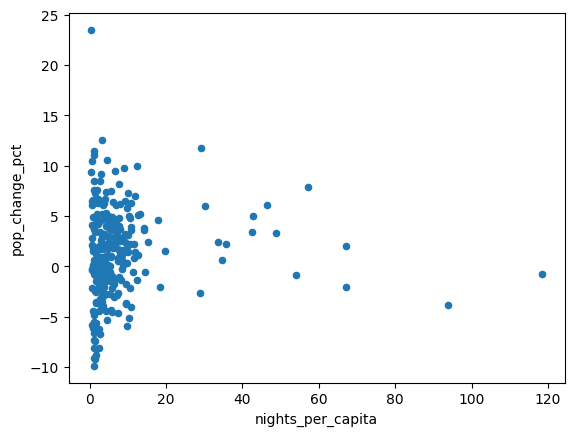

In [36]:
analysis_df.plot.scatter(x='nights_per_capita', y='pop_change_pct')

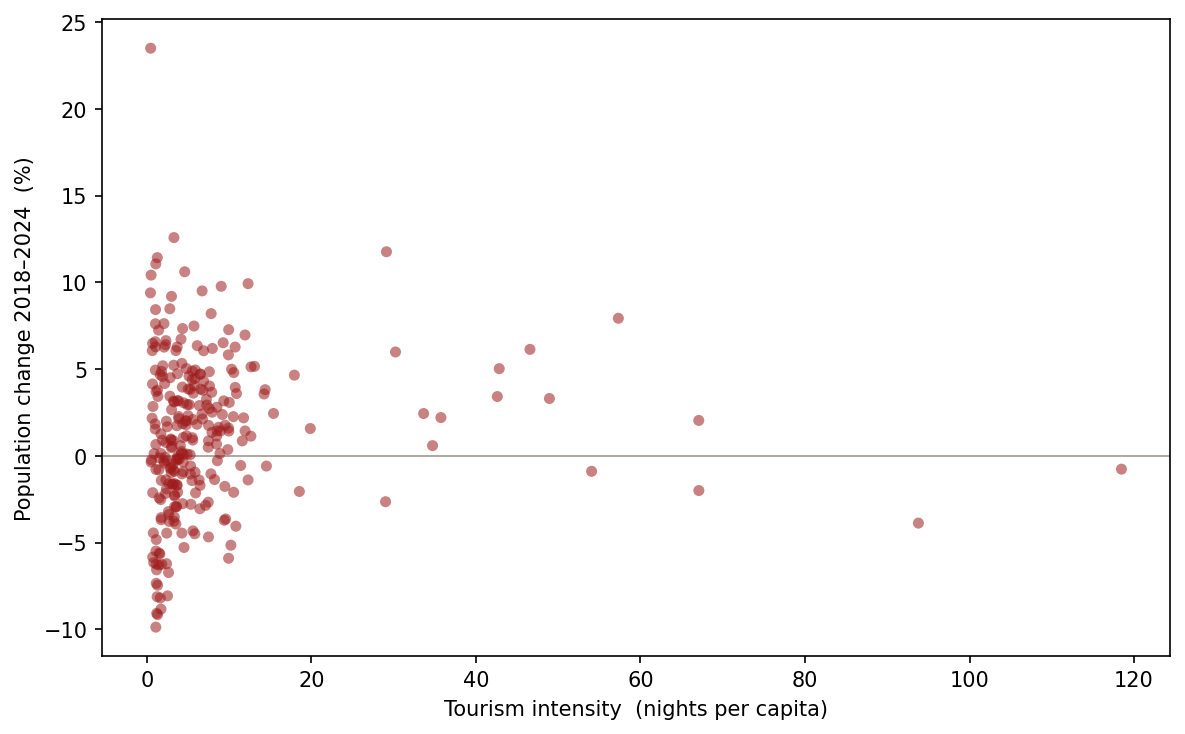

In [51]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

ax.scatter(
    analysis_df['nights_per_capita'],
    analysis_df['pop_change_pct'],
    s=28,                    # dot size
    color='#9E1B1B',         # the article's oxblood rojo
    alpha=0.55,              # slight transparency so the dense cluster reads
    edgecolor='none'
)

ax.axhline(0, color='#a3978f', linewidth=0.8, zorder=0)  # zero-population reference line

ax.set_xlabel('Tourism intensity  (nights per capita)')
ax.set_ylabel('Population change 2018–2024  (%)')

plt.tight_layout()
plt.savefig('vaciada_fig1_scatter.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [38]:
analysis_df.sort_values('nights_per_capita', ascending=False).head(10)

,nights,population_2023,pop_change_pct,nights_per_capita
geo,,,,
EL42,3.867355e+07,326433.0,-0.766207,118.473166
EL62,1.893338e+07,201877.0,-3.877780,93.786700
HR03,8.709048e+07,1297987.0,-1.999554,67.096574
ITH1,3.583325e+07,534147.0,2.042819,67.084995
ES53,6.933693e+07,1209906.0,7.933086,57.307696
EL43,3.363554e+07,622246.0,-0.890711,54.055051
AT33,3.773859e+07,771304.0,3.305642,48.928297
PT15,2.228576e+07,478618.0,6.140803,46.562731
ES70,9.477694e+07,2213016.0,5.027864,42.827047


In [39]:
analysis_df.sort_values('pop_change_pct', ascending=False).head(5)

,nights,population_2023,pop_change_pct,nights_per_capita
geo,,,,
FRY5,1.392780e+05,310199.0,23.505418,0.448996
SK01,2.388350e+06,728370.0,12.586696,3.279034
TR61,9.919423e+07,3407128.0,11.768606,29.113736
TR42,5.236447e+06,4181440.0,11.430224,1.252307
TR21,2.069107e+06,1926512.0,11.070094,1.074017


In [40]:
analysis_df.sort_values('pop_change_pct').head(5)

,nights,population_2023,pop_change_pct,nights_per_capita
geo,,,,
BG31,7.231937e+05,671502.0,-9.875839,1.076979
HR02,1.289675e+06,999106.0,-9.153552,1.290829
BG32,8.126243e+05,686334.0,-9.080352,1.184007
PL72,1.928341e+06,1133097.0,-8.836168,1.701833
RS22,2.272433e+06,1403064.0,-8.194753,1.619622


## Four base clusters and an outlier tier
If the aggregate correlation is null, the underlying structure has to be richer than a single line through the data. K-Means clustering on tourism intensity per capita and population change percentage surfaces the typology. StandardScaler standardizes the features before clustering so K-Means's Euclidean distance metric isn't dominated by the wider tourism axis. The elbow plot bends around k = 3 to 4; k = 4 is chosen because it cleanly isolates a single hyper-tourism cluster without overfitting to a preferred number of categories. A two-stage pipeline then applies a rule-based threshold split to one of the four resulting clusters: regions inside the hyper-tourism cluster with `pop_change_pct < 0` are reclassified into a separate outlier tier. The four base clusters: growing low-tourism capital metros (80 regions), the mass middle (128), growing hyper-tourism economies in Spanish islands, Austrian Alps, and Portuguese coast (9), and the vaciada depopulating interior (56). The outlier tier holds four small island and coastal tourism economies: the Greek South Aegean (EL42), the Ionian Islands (EL62), Crete (EL43), and Adriatic Croatia (HR03). The colored scatter shows this outlier tier as a distinct band below zero on the right side of the plot. The headline finding sits there: the genuine vaciada paradox is real but localized — not a Spanish story but an Aegean and Adriatic one. The popular narrative gets the dynamic right and the geography wrong.

In [41]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = analysis_df[['nights_per_capita', 'pop_change_pct']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [42]:
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertias.append(km.inertia_)

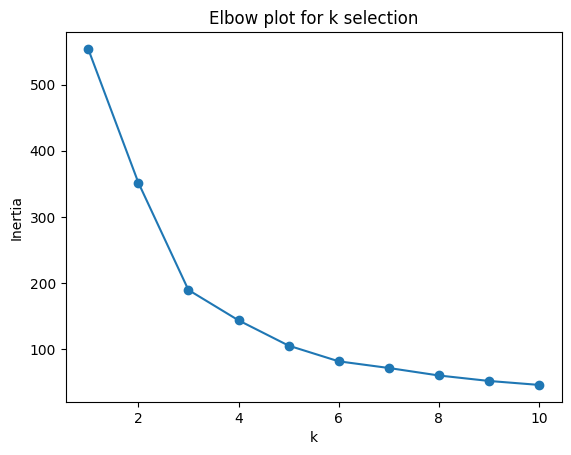

In [43]:
import matplotlib.pyplot as plt

plt.plot(range(1,11), inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow plot for k selection')
plt.show()

In [44]:
# Stage 1: K-Means at k=4 to isolate the European macro-structure

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
analysis_df['cluster'] = kmeans.fit_predict(features_scaled)

print("Cluster centroids (standardized space):")
print(kmeans.cluster_centers_)
print()
print("Cluster sizes:")
print(analysis_df['cluster'].value_counts().sort_index())

Cluster centroids (standardized space):
[[-0.1340134   1.13114253]
 [-0.33291816 -1.3377532 ]
 [-0.15723997 -0.11903724]
 [ 3.83404323  0.16130588]]

Cluster sizes:
cluster
0     80
1     58
2    126
3     13
Name: count, dtype: int64


In [45]:
# Stage 2: identify the hyper-tourism cluster programmatically, then split it by population change sign

# Column 0 of features_scaled is nights_per_capita — find the cluster with the highest centroid on that axis
hyper_tourism_idx = kmeans.cluster_centers_[:, 0].argmax()
print(f"Hyper-tourism cluster index (highest centroid on tourism axis): {hyper_tourism_idx}")

# Build the refined typology: non-hyper-tourism clusters keep their K-Means labels (0-3);
# within the hyper-tourism cluster, declining regions get a new label (4)
analysis_df['cluster_refined'] = analysis_df['cluster']

hyper_declining = (analysis_df['cluster'] == hyper_tourism_idx) & (analysis_df['pop_change_pct'] < 0)
analysis_df.loc[hyper_declining, 'cluster_refined'] = 4

print()
print("Refined cluster sizes:")
print(analysis_df['cluster_refined'].value_counts().sort_index())
print()
print("Centroid summary of refined clusters:")
print(analysis_df.groupby('cluster_refined')[['nights_per_capita', 'pop_change_pct']].mean())

Hyper-tourism cluster index (highest centroid on tourism axis): 3

Refined cluster sizes:
cluster_refined
0     80
1     58
2    126
3      9
4      4
Name: count, dtype: int64

Centroid summary of refined clusters:
                 nights_per_capita  pop_change_pct
cluster_refined                                   
0                         5.988526        6.300304
1                         3.424534       -4.729884
2                         5.689123        0.714925
3                        45.488352        3.678943
4                        83.352873       -1.883563


In [46]:
# Seed-robustness check: does the four-region declining hyper-tourism tier
# survive re-seeding, or is it an artifact of random_state=42?
# Re-runs the full Stage-1 (k=4) + Stage-2 (sign-split) pipeline across 50 seeds.

from collections import Counter

results = []

for seed in range(50):
    # Stage 1: re-fit k-means with this seed (features_scaled from cell 50)
    km = KMeans(n_clusters=4, random_state=seed, n_init=10)
    labels = km.fit_predict(features_scaled)

    # Identify the hyper-tourism cluster THIS run by centroid on the tourism
    # axis (column 0 = nights_per_capita). Never hardcode the label number —
    # k-means assigns cluster numbers arbitrarily across seeds.
    hyper_idx = km.cluster_centers_[:, 0].argmax()

    # Stage 2: the four come from the sign rule — hyper-tourism AND declining.
    # Mask is aligned to analysis_df row order (same frame features came from).
    mask = (labels == hyper_idx) & (analysis_df['pop_change_pct'].values < 0)
    declining = tuple(sorted(analysis_df.index[mask]))

    results.append(declining)

# --- Summaries ---
print("Count distribution (how many regions in the declining tier per seed):")
print(Counter(len(r) for r in results))
print()

print("Membership distribution (distinct region-sets and their frequency):")
for region_set, freq in Counter(results).most_common():
    print(f"  {freq:>2}x  {region_set}")
print()

# Eyeball check: confirm the dominant set is the RIGHT four
dominant = Counter(results).most_common(1)[0][0]
print("Dominant set:", sorted(dominant))

Count distribution (how many regions in the declining tier per seed):
Counter({4: 50})

Membership distribution (distinct region-sets and their frequency):
  50x  ('EL42', 'EL43', 'EL62', 'HR03')

Dominant set: ['EL42', 'EL43', 'EL62', 'HR03']


In [47]:
for c in sorted(analysis_df['cluster_refined'].unique()):
    members = analysis_df[analysis_df['cluster_refined'] == c].index.tolist()
    print(f"Cluster {c} (n={len(members)}):")
    print(members)
    print()

Cluster 0 (n=80):
['AT13', 'AT31', 'AT34', 'BE10', 'BE21', 'BE22', 'BE23', 'BE24', 'BE34', 'CH01', 'CH02', 'CH03', 'CH04', 'CH05', 'CH06', 'CZ01', 'CZ02', 'CZ03', 'DK01', 'DK04', 'EL41', 'ES22', 'ES30', 'ES51', 'ES52', 'ES62', 'FI1B', 'FI20', 'FRG0', 'FRH0', 'FRI1', 'FRJ1', 'FRJ2', 'FRK2', 'FRL0', 'FRM0', 'FRY3', 'FRY4', 'FRY5', 'HU12', 'IE04', 'IE05', 'IE06', 'LT01', 'NL22', 'NL23', 'NL32', 'NL35', 'NL36', 'NL41', 'NO06', 'NO08', 'NO09', 'NO0A', 'PL91', 'SE11', 'SE12', 'SE22', 'SE23', 'SI04', 'SK01', 'TR10', 'TR21', 'TR22', 'TR31', 'TR32', 'TR33', 'TR41', 'TR42', 'TR51', 'TR52', 'TR61', 'TR62', 'TR71', 'TR72', 'TR82', 'TR90', 'TRC1', 'TRC2', 'TRC3']

Cluster 1 (n=58):
['BG31', 'BG32', 'BG33', 'BG34', 'BG41', 'BG42', 'DED4', 'DEE0', 'EL51', 'EL52', 'EL53', 'EL61', 'EL63', 'EL64', 'EL65', 'ES63', 'FRY2', 'HR02', 'HR06', 'HU11', 'HU23', 'HU31', 'HU32', 'HU33', 'ITC1', 'ITF1', 'ITF2', 'ITF3', 'ITF4', 'ITF5', 'ITF6', 'ITG1', 'ITG2', 'ITI2', 'ITI3', 'PL22', 'PL42', 'PL43', 'PL51', 'PL52', '

In [48]:
print(analysis_df['cluster_refined'].value_counts().sort_index())
analysis_df.groupby('cluster_refined')[['nights_per_capita', 'pop_change_pct']].mean()

cluster_refined
0     80
1     58
2    126
3      9
4      4
Name: count, dtype: int64


,nights_per_capita,pop_change_pct
cluster_refined,,
0,5.988526,6.300304
1,3.424534,-4.729884
2,5.689123,0.714925
3,45.488352,3.678943
4,83.352873,-1.883563


<Axes: xlabel='nights_per_capita', ylabel='pop_change_pct'>

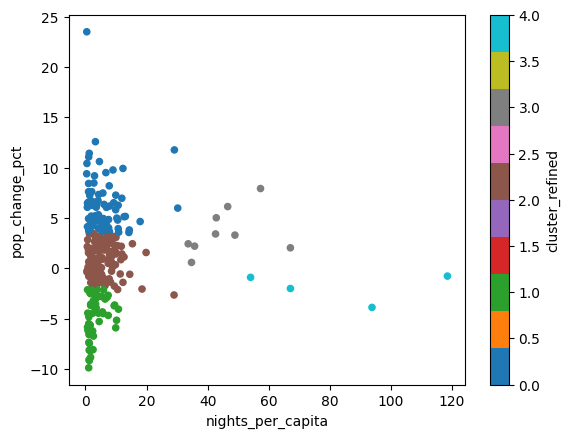

In [50]:
analysis_df.plot.scatter(x='nights_per_capita', y='pop_change_pct', c='cluster_refined', cmap='tab10')

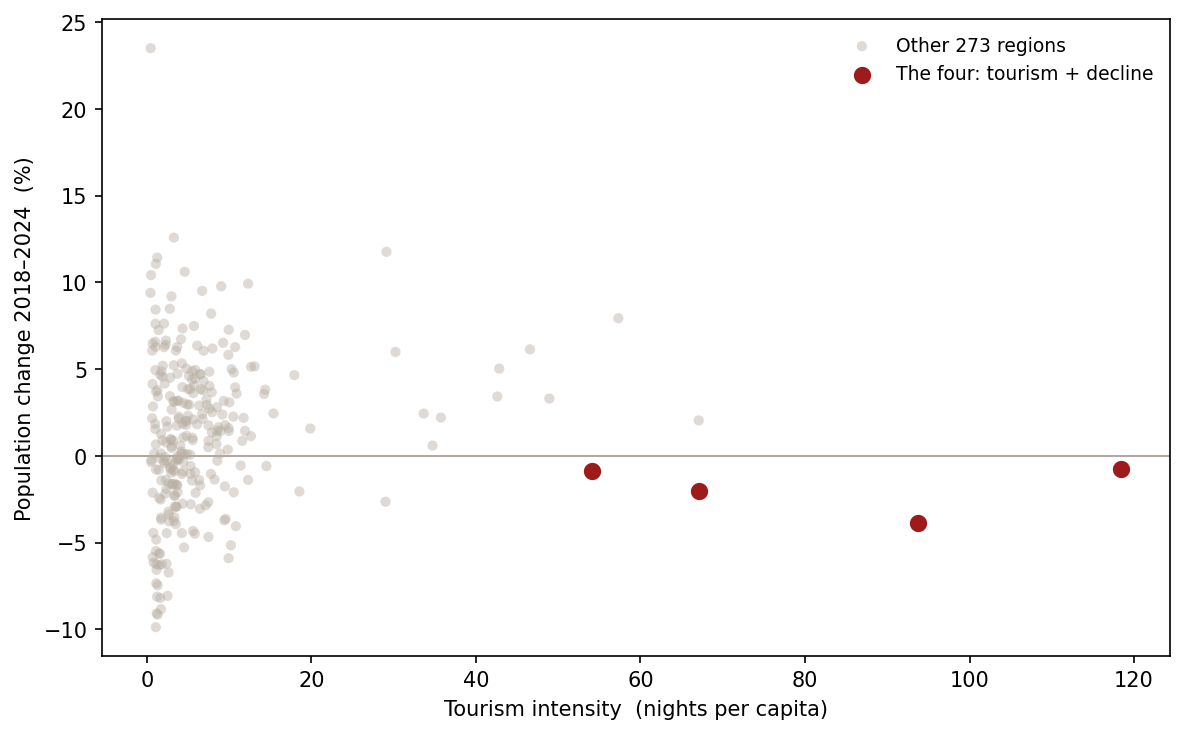

In [57]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

# Split the data: the four outlier regions vs. everyone else
is_outlier = analysis_df['cluster_refined'] == 4
others = analysis_df[~is_outlier]
four   = analysis_df[is_outlier]

# Background: all other regions in muted grey
ax.scatter(
    others['nights_per_capita'], others['pop_change_pct'],
    s=24, color='#b8 afa2'.replace(' ',''), alpha=0.45, edgecolor='none',
    label='Other 273 regions'
)

# Foreground: the four, in oxblood, larger, outlined
ax.scatter(
    four['nights_per_capita'], four['pop_change_pct'],
    s=90, color='#9E1B1B', edgecolor='white', linewidth=1.2, zorder=5,
    label='The four: tourism + decline'
)

ax.axhline(0, color='#a3978f', linewidth=0.8, zorder=0)
ax.set_xlabel('Tourism intensity  (nights per capita)')
ax.set_ylabel('Population change 2018–2024  (%)')
ax.legend(frameon=False, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('vaciada_fig2_clusters.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Synthesis

The analytical journey: a popular claim that overtourism produces depopulation, a near-zero aggregate correlation across 277 European NUTS-2 regions (r = 0.05) once tourism intensity and population change are measured directly, and a typological partition that surfaces structure the aggregate hid. Of the resulting groups, one — a four-region outlier tier — carries the genuine pattern: the Greek South Aegean, the Ionian Islands, Crete, and Adriatic Croatia. These are small island and coastal economies where tourism saturation co-occurs with measurable population decline. Spain, which owns the linguistic and political narrative of vaciada, does not appear in this group at the NUTS-2 scale.

That absence is the analytical contribution. Spain's interior does lose population (the vaciada literature is not wrong); Spain's tourism is highly concentrated (second-highest Gini in Europe after Turkey, on a small-sample-reliable measure); but the two patterns occupy different regions within Spain. The interior depopulates while the coasts and islands grow. The popular framing that conflates Spanish overtourism with Spanish depopulation does not hold at the regional resolution Eurostat makes available.

Limitations to keep in view: the outlier tier is small (n = 4), and calling four regions a "cluster" is generous; the clustering uses only two features, with tourism intensity measured as a 2022–2024 mean to smooth post-COVID volatility; population change is a net measure that conflates births, deaths, and migration without decomposition; and the analysis remains associational rather than causal. The narrative framing of these results — and what they mean for tourism policy and regional development — is taken up in the somewhere-else.org piece this notebook accompanies.

In [52]:
import base64

with open('vaciada_fig1_scatter.png', 'rb') as f:
    encoded = base64.b64encode(f.read()).decode('utf-8')

print(len(encoded), 'characters')
print(encoded[:80])

92576 characters
iVBORw0KGgoAAAANSUhEUgAABKEAAALeCAYAAAByYwIJAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGli


In [56]:
import base64

with open('vaciada_fig1_scatter.png', 'rb') as f:
    fig1_b64 = base64.b64encode(f.read()).decode('utf-8')

# Anchor on text we've confirmed is in the file
anchor = 'uncoloured EU scatter'
a = html.find(anchor)
print("anchor found at:", a)

if a != -1:
    # walk backward to the start of this div, forward to its close
    start = html.rfind('<div class="ph">', 0, a)
    end   = html.find('</div>', a) + len('</div>')
    print("div start:", start, " div end:", end)
    print("---- block being replaced ----")
    print(repr(html[start:end]))

    img_1 = f'<img src="data:image/png;base64,{fig1_b64}" alt="Scatter of tourism intensity against population change across 277 European regions, showing no correlation" style="width:100%;height:auto;display:block;">'

    new_html = html[:start] + img_1 + html[end:]
    with open('vaciada_paradox_article_figures.html', 'w', encoding='utf-8') as f:
        f.write(new_html)
    html = new_html   # keep in memory for Figure 2 later
    print("✓ Saved with Figure 1 embedded")
else:
    print("✗ anchor text not found — paste Claude the repr from the diagnostic cell")

anchor found at: 13751
div start: 13722  div end: 13911
---- block being replaced ----
'<div class="ph">[ FIGURE 1 — uncoloured EU scatter ]<br>tourism nights per capita (x) &times; 2018&ndash;2024 population change (y)<br>drop in the plain scatter from the notebook here</div>'
✓ Saved with Figure 1 embedded


In [58]:
import base64

with open('vaciada_fig2_clusters.png', 'rb') as f:
    fig2_b64 = base64.b64encode(f.read()).decode('utf-8')

anchor = 'coloured cluster scatter'
a = html.find(anchor)
print("anchor found at:", a)

if a != -1:
    start = html.rfind('<div class="ph">', 0, a)
    end   = html.find('</div>', a) + len('</div>')
    print("div start:", start, " div end:", end)
    print("---- block being replaced ----")
    print(repr(html[start:end]))

    img_2 = f'<img src="data:image/png;base64,{fig2_b64}" alt="Scatter of all European regions with the four tourism-and-declining outlier regions highlighted in oxblood, far out on the tourism axis and below zero population change" style="width:100%;height:auto;display:block;">'

    new_html = html[:start] + img_2 + html[end:]
    with open('vaciada_paradox_article_figures.html', 'w', encoding='utf-8') as f:
        f.write(new_html)
    html = new_html
    print("✓ Saved with Figure 2 embedded")
else:
    print("✗ anchor not found — paste Claude the repr")

anchor found at: 108049
div start: 108020  div end: 108194
---- block being replaced ----
'<div class="ph">[ FIGURE 2 — coloured cluster scatter ]<br>same axes as Figure 1, points coloured by cluster<br>drop in the coloured cluster plot from the notebook here</div>'
✓ Saved with Figure 2 embedded


In [59]:
analysis_df.to_csv('analysis_df.csv')